
TensorFlow Version: 2.20.0

Loading dataset with Batch Size: 8...
Found 11993 files belonging to 3 classes.
Using 9595 files for training.
Found 11993 files belonging to 3 classes.
Using 2398 files for validation.
Classes: ['Neck_Blast', 'Rice Hispa', 'Sheath Blight']

Building Model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          81,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,136,870 (15.78 MB)

 Trainable params: 84,739 (331.01 KB)

 Non-trainable params: 4,052,131 (15.46 MB)


Starting Training...
Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 262s 210ms/step - accuracy: 0.9372 - loss: 0.1725 - val_accuracy: 0.9937 - val_loss: 0.0236
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 251s 209ms/step - accuracy: 0.9715 - loss: 0.0800 - val_accuracy: 0.9967 - val_loss: 0.0126
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 245s 204ms/step - accuracy: 0.9782 - loss: 0.0610 - val_accuracy: 0.9971 - val_loss: 0.0103
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 255s 212ms/step - accuracy: 0.9794 - loss: 0.0624 - val_accuracy: 0.9983 - val_loss: 0.0078
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 247s 206ms/step - accuracy: 0.9828 - loss: 0.0524 - val_accuracy: 0.9992 - val_loss: 0.0038
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 260s 217ms/step - accuracy: 0.9843 - loss: 0.0469 - val_accuracy: 0.9987 - val_loss: 0.0061
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 250s 208ms/step - accuracy: 0.9836 - loss: 0.0423 - val_accuracy: 0.9983 - val_loss: 0.0051
Epoch 8/10
1200/1200 ━━━━━━━━━━━━━━━━━━━

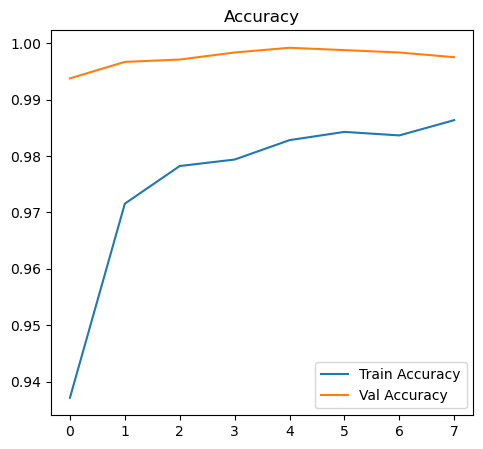

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import os
import gc # Garbage collection for memory management

# Force clean session start
tf.keras.backend.clear_session()
gc.collect()

print("TensorFlow Version:", tf.__version__)

# ============================================================
# 1. CRITICAL SETTINGS FOR STABILITY
# ============================================================

DATA_DIR = "rice"
IMG_SIZE = (224, 224)

# BATCH SIZE 8 is the "Magic Number" for 16GB Shared RAM
# It is slower, but it will NOT crash.
BATCH_SIZE = 8 
EPOCHS = 10

# ============================================================
# 2. LOAD DATASET
# ============================================================

print(f"\nLoading dataset with Batch Size: {BATCH_SIZE}...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"Classes: {class_names}")

# ============================================================
# 3. PIPELINE OPTIMIZATION
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

# prefetch allows the CPU to prepare the next batch while GPU works
# We do NOT use .cache() as it consumes too much RAM
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# ============================================================
# 4. MODEL ARCHITECTURE
# ============================================================

print("\nBuilding Model...")

# Data Augmentation (Runs inside model)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Base Model
base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False # Freeze weights

# Architecture
model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    
    data_augmentation,
    
    # CRITICAL FIX: EfficientNet expects 0-255 pixel values. 
    # Removed layers.Rescaling(1./255) because it hurts accuracy for this specific model.
    
    base_model,
    
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    
    # Reduced Dense layer size from 128 to 64 to save memory
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    
    layers.Dense(NUM_CLASSES, activation="softmax")
])

# ============================================================
# 5. COMPILE
# ============================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ============================================================
# 6. TRAIN (With Memory Safety)
# ============================================================

callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ModelCheckpoint("rice_safe_model.keras", save_best_only=True, monitor="val_accuracy")
]

print("\nStarting Training...")

# We wrap fit in a try-catch block to handle OOM (Out of Memory) gracefully
try:
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks
    )
except Exception as e:
    print(f"\nCRASH PREVENTED: {e}")
    print("Tip: If this happened, change BATCH_SIZE to 4.")

# ============================================================
# 7. SAVE & PLOT
# ============================================================

model.save("rice_final_optimized.keras")
print("\nModel saved.")

if 'history' in locals():
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title("Accuracy")
    plt.legend()
    plt.show()

# ============================================================
# 8. PREDICTION (CORRECTED)
# ============================================================

def predict_safe(img_path):
    if not os.path.exists(img_path):
        return

    img = keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    # CRITICAL: Do NOT divide by 255.0 for EfficientNet here either
    # EfficientNet has internal preprocessing layers
    
    prediction = model.predict(img_array)
    idx = np.argmax(prediction)
    print(f"Prediction: {class_names[idx]} ({np.max(prediction)*100:.2f}%)")

# predict_safe("test.jpg")

In [2]:
model.save("rice_disease_efficientnetb0.keras")


In [3]:
model.save("rice_disease_model.h5")


In [4]:
# ============================================================
# MODEL EVALUATION: CONFUSION MATRIX & CLASSIFICATION REPORT
# ============================================================

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

# ============================================================
# LOAD MODEL
# ============================================================

model = keras.models.load_model("rice_disease_model.h5")

print("Model loaded successfully")

# ============================================================
# LOAD VALIDATION DATASET
# ============================================================

DATA_DIR = "rice"
IMG_SIZE = (224,224)
BATCH_SIZE = 16

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False   # IMPORTANT
)

class_names = val_ds.class_names

print("Classes:", class_names)

# ============================================================
# GET TRUE LABELS
# ============================================================

y_true = []

for images, labels in val_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# ============================================================
# GET PREDICTIONS
# ============================================================

y_pred_probs = model.predict(val_ds)

y_pred = np.argmax(y_pred_probs, axis=1)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================================
# ACCURACY GRAPH (OPTIONAL)
# ============================================================

accuracy = np.mean(y_true == y_pred)

print(f"\nOverall Accuracy: {accuracy*100:.2f}%")


Model loaded successfully
Found 11993 files belonging to 3 classes.
Using 2398 files for validation.
Classes: ['Neck_Blast', 'Rice Hispa', 'Sheath Blight']
150/150 ━━━━━━━━━━━━━━━━━━━━ 43s 274ms/step

Classification Report:



ValueError: Number of classes, 2, does not match size of target_names, 3. Try specifying the labels parameter

               precision    recall  f1-score   support

   Neck_Blast       0.00      0.00      0.00         0
   Rice Hispa       0.00      0.00      0.00         0
Sheath Blight       1.00      0.96      0.98      2398

     accuracy                           0.96      2398
    macro avg       0.33      0.32      0.33      2398
 weighted avg       1.00      0.96      0.98      2398



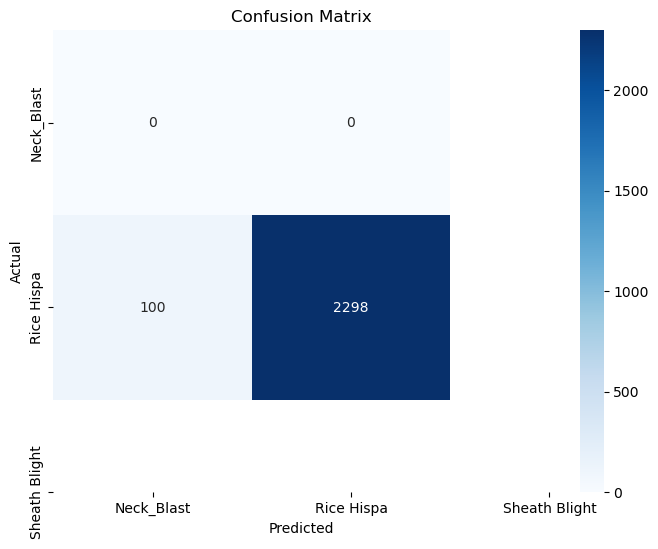

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Classification report
report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    zero_division=0
)

print(report)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


Checking for model...
Loading Validation Data...
Found 11993 files belonging to 3 classes.
Using 2398 files for validation.
Classes Found (3): ['Neck_Blast', 'Rice Hispa', 'Sheath Blight']
Loading Model...
Generating Predictions (This may take a minute)...
Plotting Matrix...


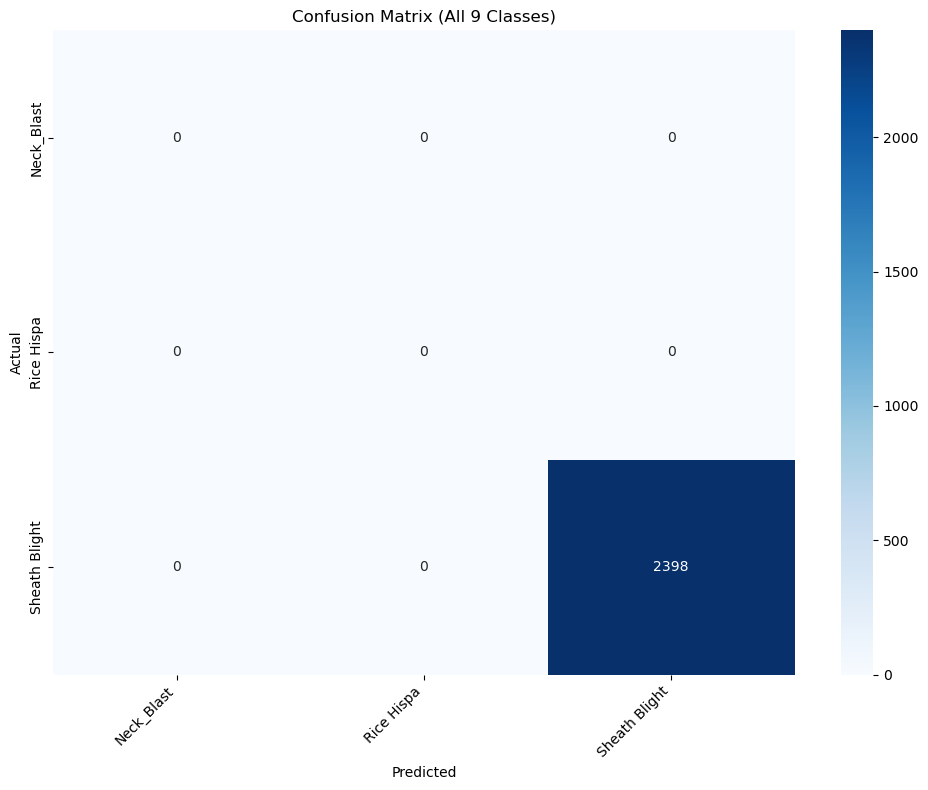


Classification Report:


ValueError: Number of classes, 1, does not match size of target_names, 3. Try specifying the labels parameter

In [6]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# --- 1. SETUP ---
DATA_DIR = "rice"
IMG_SIZE = (224, 224)
BATCH_SIZE = 8 # Keep low to prevent crashing
MODEL_PATH = "rice_final_optimized.keras"

print("Checking for model...")
if not os.path.exists(MODEL_PATH):
    print(f"❌ Error: Model file '{MODEL_PATH}' not found. Train the model first!")
    exit()

# --- 2. LOAD VALIDATION DATA (NO SHUFFLE) ---
# We disable shuffling for evaluation so labels match predictions perfectly
print("Loading Validation Data...")

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False  # CRITICAL: Keep False for Confusion Matrix to align correctly
)

class_names = val_ds.class_names
print(f"Classes Found ({len(class_names)}): {class_names}")

# --- 3. LOAD TRAINED MODEL ---
print("Loading Model...")
model = keras.models.load_model(MODEL_PATH)

# --- 4. GENERATE PREDICTIONS ---
print("Generating Predictions (This may take a minute)...")

y_true = []
y_pred = []

# Iterate over the entire validation dataset
for images, labels in val_ds:
    # 1. Get True Labels
    y_true.extend(labels.numpy())
    
    # 2. Get Model Predictions
    preds = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    y_pred.extend(pred_labels)

# --- 5. COMPUTE CONFUSION MATRIX ---
print("Plotting Matrix...")
# Force the matrix to include ALL classes, even if some were never predicted
# This ensures the heatmap is always 9x9 (or however many classes you have)
cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))

# --- 6. PLOT ---
plt.figure(figsize=(10, 8)) # Big size to fit all 9 classes
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (All 9 Classes)')
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.tight_layout()
plt.show()

# --- 7. PRINT REPORT ---
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Checking for model...
Loading Validation Data...
Found 11993 files belonging to 3 classes.
Using 2398 files for validation.
Classes Found: ['Neck_Blast', 'Rice Hispa', 'Sheath Blight']
Loading Model...
Generating Predictions...

--- Validation Data Distribution ---
Neck_Blast: 74 images
Rice Hispa: 959 images
Sheath Blight: 1365 images

Plotting Matrix...


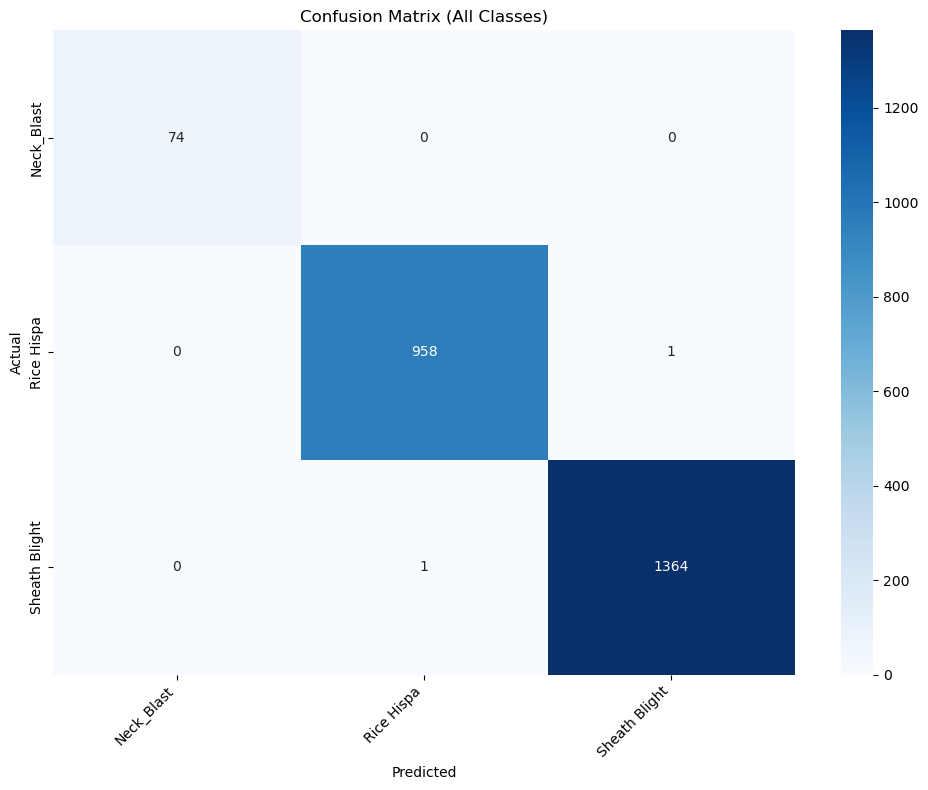


Classification Report:
               precision    recall  f1-score   support

   Neck_Blast       1.00      1.00      1.00        74
   Rice Hispa       1.00      1.00      1.00       959
Sheath Blight       1.00      1.00      1.00      1365

     accuracy                           1.00      2398
    macro avg       1.00      1.00      1.00      2398
 weighted avg       1.00      1.00      1.00      2398



In [7]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# --- 1. SETUP ---
DATA_DIR = "rice"
IMG_SIZE = (224, 224)
BATCH_SIZE = 8
MODEL_PATH = "rice_final_optimized.keras"

print("Checking for model...")
if not os.path.exists(MODEL_PATH):
    print(f"❌ Error: Model file '{MODEL_PATH}' not found. Train the model first!")
    exit()

# --- 2. LOAD VALIDATION DATA ---
# FIX: shuffle=True ensures we get a random mix of ALL classes, 
# not just the last few alphabetical folders.
print("Loading Validation Data...")

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True 
)

class_names = val_ds.class_names
print(f"Classes Found: {class_names}")

# --- 3. LOAD TRAINED MODEL ---
print("Loading Model...")
model = keras.models.load_model(MODEL_PATH)

# --- 4. GENERATE PREDICTIONS ---
print("Generating Predictions...")

y_true = []
y_pred = []

# Iterate through the dataset
for images, labels in val_ds:
    # Get True Labels
    y_true.extend(labels.numpy())
    
    # Get Model Predictions
    preds = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    y_pred.extend(pred_labels)

# --- 5. VERIFY CLASS DISTRIBUTION (DEBUGGING) ---
# This proves that 'Brown Spot' is actually in the data now
print("\n--- Validation Data Distribution ---")
unique, counts = np.unique(y_true, return_counts=True)
count_dict = dict(zip(unique, counts))

for i, name in enumerate(class_names):
    count = count_dict.get(i, 0)
    print(f"{name}: {count} images")
    if count == 0:
        print(f"⚠️ WARNING: No images found for {name} in validation set!")

# --- 6. COMPUTE CONFUSION MATRIX ---
print("\nPlotting Matrix...")
cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))

# --- 7. PLOT ---
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (All Classes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 8. PRINT REPORT ---
print("\nClassification Report:")
print(classification_report(
    y_true, 
    y_pred, 
    target_names=class_names, 
    labels=range(len(class_names))
))